<a href="https://colab.research.google.com/github/atshaya1208/Bitcoin_prj5/blob/main/Project5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/Bitcoin Historical Data (1).csv")

In [ ]:
df.shape

(4999, 7)

In [ ]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,24-03-2024,"67,211.9","64,036.5","67,587.8","63,812.9",65.59K,4.96%
1,23-03-2024,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%
2,22-03-2024,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
3,21-03-2024,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
4,20-03-2024,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%


Cleaning

In [ ]:
df.dtypes

,0
Date,object
Price,object
Open,object
High,object
Low,object
Vol.,object
Change %,object


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Date']

,Date
0,2024-03-24
1,2024-03-23
2,2024-03-22
3,2024-03-21
4,2024-03-20
...,...
4994,2010-07-22
4995,2010-07-21
4996,2010-07-20
4997,2010-07-19


In [ ]:
df['Date'].isnull().sum()

np.int64(0)

In [ ]:
df['Date'].duplicated().sum()

np.int64(0)

In [ ]:
df = df.sort_values('Date').reset_index(drop=True)

In [ ]:
df['Price']

,Price
0,0.1
1,0.1
2,0.1
3,0.1
4,0.1
...,...
4994,"67,854.0"
4995,"65,503.8"
4996,"63,785.5"
4997,"64,037.8"


In [ ]:
df['Price'] = df['Price'].str.replace(',', '').astype(float)

In [ ]:
df['Price']

,Price
0,0.1
1,0.1
2,0.1
3,0.1
4,0.1
...,...
4994,67854.0
4995,65503.8
4996,63785.5
4997,64037.8


Sliding window implementation

In [ ]:

sequence_length = 60

X = []
y_1d = []
y_3d = []
y_7d = []
dates_y = []

prices = df['Price'].values
dates = df['Date'].values

for i in range(len(prices) - sequence_length - 7 + 1):
    X.append(prices[i : i + sequence_length])
    y_1d.append(prices[i + sequence_length])
    y_3d.append(prices[i + sequence_length + 2])
    y_7d.append(prices[i + sequence_length + 6])
    dates_y.append(dates[i + sequence_length])

X = np.array(X)
y_1d = np.array(y_1d)
y_3d = np.array(y_3d)
y_7d = np.array(y_7d)

print(f"X shape: {X.shape}")
print(f"y_1d shape: {y_1d.shape}")

columns = [f'Lag_{i}' for i in range(sequence_length, 0, -1)]
prepared_df = pd.DataFrame(X, columns=columns)
prepared_df['Target_Date'] = dates_y
prepared_df['Target_Price_1D'] = y_1d
prepared_df['Target_Price_3D'] = y_3d
prepared_df['Target_Price_7D'] = y_7d

target_cols = ['Target_Price_1D', 'Target_Price_3D', 'Target_Price_7D']
prepared_df = prepared_df[['Target_Date'] + columns + target_cols]

prepared_df.to_csv("bitcoin_sliding_window_60d.csv", index=False)

print(prepared_df.head(2))

X shape: (4933, 60)
y_1d shape: (4933,)
  Target_Date  Lag_60  Lag_59  Lag_58  Lag_57  Lag_56  Lag_55  Lag_54  Lag_53  \
0  2010-09-16     0.1     0.1     0.1     0.1     0.1     0.1     0.1     0.1   
1  2010-09-17     0.1     0.1     0.1     0.1     0.1     0.1     0.1     0.1   

   Lag_52  ...  Lag_7  Lag_6  Lag_5  Lag_4  Lag_3  Lag_2  Lag_1  \
0     0.1  ...    0.1    0.1    0.1    0.1    0.1    0.1    0.1   
1     0.1  ...    0.1    0.1    0.1    0.1    0.1    0.1    0.1   

   Target_Price_1D  Target_Price_3D  Target_Price_7D  
0              0.1              0.1              0.1  
1              0.1              0.1              0.1  

[2 rows x 64 columns]


In [ ]:
prepared_df

,Target_Date,Lag_60,Lag_59,Lag_58,Lag_57,Lag_56,Lag_55,Lag_54,Lag_53,Lag_52,...,Lag_7,Lag_6,Lag_5,Lag_4,Lag_3,Lag_2,Lag_1,Target_Price_1D,Target_Price_3D,Target_Price_7D
0,2010-09-16,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
1,2010-09-17,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2,2010-09-18,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
3,2010-09-19,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
4,2010-09-20,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4928,2024-03-14,41746.1,42510.7,43145.5,42768.7,41292.7,41648.0,41695.4,41583.2,39556.4,...,66855.3,68172.0,68366.5,68964.8,72099.1,71470.2,73066.3,71387.5,65314.2,67854.0
4929,2024-03-15,42510.7,43145.5,42768.7,41292.7,41648.0,41695.4,41583.2,39556.4,39888.8,...,68172.0,68366.5,68964.8,72099.1,71470.2,73066.3,71387.5,69463.7,68391.2,65503.8
4930,2024-03-16,43145.5,42768.7,41292.7,41648.0,41695.4,41583.2,39556.4,39888.8,40086.0,...,68366.5,68964.8,72099.1,71470.2,73066.3,71387.5,69463.7,65314.2,67594.1,63785.5
4931,2024-03-17,42768.7,41292.7,41648.0,41695.4,41583.2,39556.4,39888.8,40086.0,39935.7,...,68964.8,72099.1,71470.2,73066.3,71387.5,69463.7,65314.2,68391.2,62050.0,64037.8


In [ ]:
prepared_df.dtypes


,0
Target_Date,datetime64[ns]
Lag_60,float64
Lag_59,float64
Lag_58,float64
Lag_57,float64
...,...
Lag_2,float64
Lag_1,float64
Target_Price_1D,float64
Target_Price_3D,float64


Spliting

In [ ]:

train_df = prepared_df[prepared_df['Target_Date'].dt.year < 2023].reset_index(drop=True)
val_df   = prepared_df[prepared_df['Target_Date'].dt.year == 2022].reset_index(drop=True)
test_df  = prepared_df[prepared_df['Target_Date'].dt.year.isin([2023, 2024])].reset_index(drop=True)

print(f"Training set rows (2010 - 2022): {len(train_df)}")
print(f"Validation set rows (2022): {len(val_df)}")
print(f"Test set rows (2023-2024): {len(test_df)}")

Training set rows (2010 - 2022): 4490
Validation set rows (2022): 365
Test set rows (2023-2024): 443


Scaling

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

lag_features = [col for col in prepared_df.columns if col.startswith('Lag_')]
target_features = ['Target_Price_1D', 'Target_Price_3D', 'Target_Price_7D']

X_train_raw = train_df[lag_features].values
y_train_raw = train_df[target_features].values

X_val_raw   = val_df[lag_features].values
y_val_raw   = val_df[target_features].values

X_test_raw  = test_df[lag_features].values
y_test_raw  = test_df[target_features].values

scaler = MinMaxScaler(feature_range=(0, 1))

scaler.fit(X_train_raw.reshape(-1, 1))

X_train_scaled = scaler.transform(X_train_raw.reshape(-1, 1)).reshape(X_train_raw.shape)
X_val_scaled   = scaler.transform(X_val_raw.reshape(-1, 1)).reshape(X_val_raw.shape)
X_test_scaled  = scaler.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape)


y_train_scaled = scaler.transform(y_train_raw.reshape(-1, 1)).reshape(y_train_raw.shape)
y_val_scaled   = scaler.transform(y_val_raw.reshape(-1, 1)).reshape(y_val_raw.shape)
y_test_scaled  = scaler.transform(y_test_raw.reshape(-1, 1)).reshape(y_test_raw.shape)

In [51]:
import pickle

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler.fit, file)


In [ ]:

X_train = np.expand_dims(X_train_scaled, axis=-1)
X_val   = np.expand_dims(X_val_scaled, axis=-1)
X_test  = np.expand_dims(X_test_scaled, axis=-1)

y_train = y_train_scaled
y_val   = y_val_scaled
y_test  = y_test_scaled

print("--- Final Scaled Dataset Matrix Shapes ---")
print(f"X_train: {X_train.shape}  -> y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  -> y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  -> y_test:  {y_test.shape}")

--- Final Scaled Dataset Matrix Shapes ---
X_train: (4490, 60, 1)  -> y_train: (4490, 3)
X_val:   (365, 60, 1)  -> y_val:   (365, 3)
X_test:  (443, 60, 1)  -> y_test:  (443, 3)


In [53]:
np.save('X_test.npy', X_test)
np.save('y_test.npy', y_test)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class PyTorchForecastDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64

train_dataset = PyTorchForecastDataset(X_train, y_train)
val_dataset = PyTorchForecastDataset(X_val, y_val)
test_dataset = PyTorchForecastDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
import torch.nn as nn

# --- 1D-CNN Model ---
class CNN1DForecaster(nn.Module):
    def __init__(self, input_timesteps, output_dim=3):
        super(CNN1DForecaster, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.flatten = nn.Flatten()

        flattened_size = (input_timesteps // 2) * 32
        self.fc = nn.Linear(flattened_size, output_dim)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool(self.relu(self.conv1(x)))
        x = self.flatten(x)
        return self.fc(x)


# --- LSTM Model ---
class LSTMForecaster(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, output_dim=3):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


# --- Transformer Model ---
class TransformerForecaster(nn.Module):
    def __init__(self, input_dim=1, d_model=64, nhead=4, num_layers=2, output_dim=3, timesteps=10):
        super(TransformerForecaster, self).__init__()
        self.input_projection = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(d_model * timesteps, output_dim)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.transformer_encoder(x)
        x = self.flatten(x)
        return self.fc(x)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, device='cpu'):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
timesteps = X_train.shape[1]

print("Training LSTM Model...")
lstm_model = LSTMForecaster(input_dim=1, hidden_dim=64, num_layers=2, output_dim=3)
lstm_model = train_model(lstm_model, train_loader, val_loader, epochs=15, device=device)

Training LSTM Model...
Epoch 1/15 | Train Loss: 0.019729 | Val Loss: 0.002565
Epoch 2/15 | Train Loss: 0.001021 | Val Loss: 0.001763
Epoch 3/15 | Train Loss: 0.000888 | Val Loss: 0.001787
Epoch 4/15 | Train Loss: 0.000902 | Val Loss: 0.001629
Epoch 5/15 | Train Loss: 0.000764 | Val Loss: 0.002046
Epoch 6/15 | Train Loss: 0.000699 | Val Loss: 0.001490
Epoch 7/15 | Train Loss: 0.000699 | Val Loss: 0.001365
Epoch 8/15 | Train Loss: 0.000645 | Val Loss: 0.002120
Epoch 9/15 | Train Loss: 0.000623 | Val Loss: 0.002141
Epoch 10/15 | Train Loss: 0.000642 | Val Loss: 0.001984
Epoch 11/15 | Train Loss: 0.000582 | Val Loss: 0.003747
Epoch 12/15 | Train Loss: 0.000583 | Val Loss: 0.002412
Epoch 13/15 | Train Loss: 0.000629 | Val Loss: 0.001424
Epoch 14/15 | Train Loss: 0.000540 | Val Loss: 0.001245
Epoch 15/15 | Train Loss: 0.000571 | Val Loss: 0.001124


In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_and_inverse(model, data_loader, scaler, target_shape, device='cpu'):
    model.eval()
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            all_preds.append(outputs.cpu().numpy())
            all_trues.append(y_batch.numpy())

    preds_scaled = np.vstack(all_preds)
    trues_scaled = np.vstack(all_trues)
    preds_original = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(target_shape)
    trues_original = scaler.inverse_transform(trues_scaled.reshape(-1, 1)).reshape(target_shape)

    return preds_original, trues_original

def calculate_regression_metrics(y_true, y_pred):
    horizons = ['1-Day', '3-Day', '7-Day']
    metrics_summary = {}

    for i, horizon in enumerate(horizons):
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mape = np.mean(np.abs((y_true[:, i] - y_pred[:, i]) / (y_true[:, i] + 1e-5))) * 100

        metrics_summary[horizon] = {'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

    return pd.DataFrame(metrics_summary).T

y_pred_orig, y_true_orig = evaluate_and_inverse(lstm_model, test_loader, scaler, y_test.shape, device)

metrics_df = calculate_regression_metrics(y_true_orig, y_pred_orig)
print("\n--- Test Set Metrics Evaluation ---")
print(metrics_df)


--- Test Set Metrics Evaluation ---
               MAE         RMSE  MAPE (%)
1-Day   936.311035  1486.308935  2.737294
3-Day  1406.132080  2168.249986  4.049782
7-Day  2056.686035  3181.231680  5.769495


In [54]:
torch.save(lstm_model.state_dict(), 'lstm_model.pth')

np.save('y_pred_orig.npy', y_pred_orig)
np.save('y_true_orig.npy', y_true_orig)

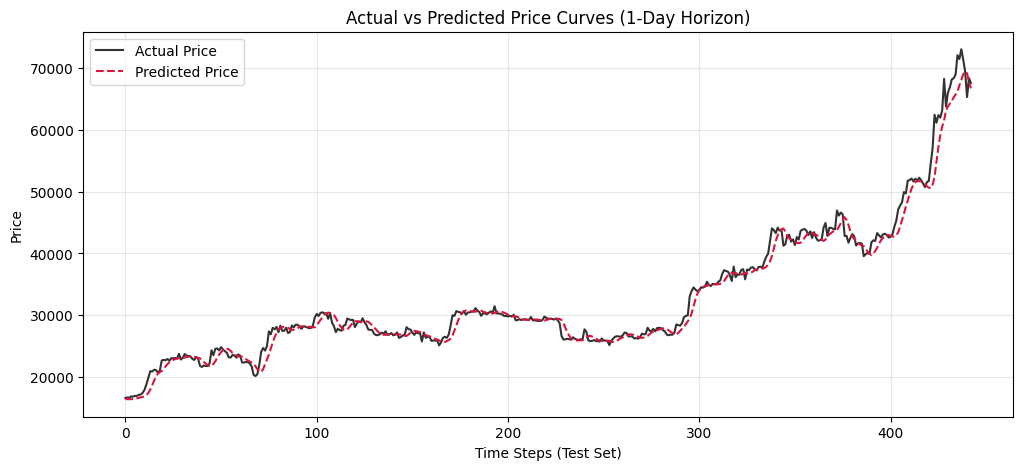

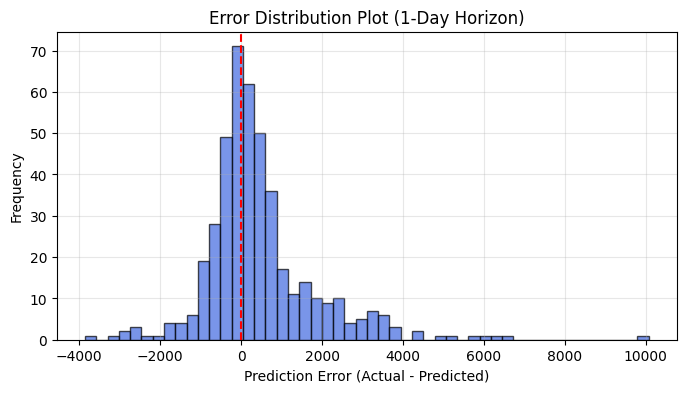

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions_vs_actuals(y_true, y_pred, horizon_idx=0, horizon_name='1-Day'):
    plt.figure(figsize=(12, 5))
    plt.plot(y_true[:, horizon_idx], label='Actual Price', color='black', alpha=0.8)
    plt.plot(y_pred[:, horizon_idx], label='Predicted Price', color='crimson', linestyle='--')
    plt.title(f'Actual vs Predicted Price Curves ({horizon_name} Horizon)')
    plt.xlabel('Time Steps (Test Set)')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_error_distribution(y_true, y_pred, horizon_idx=0, horizon_name='1-Day'):
    errors = y_true[:, horizon_idx] - y_pred[:, horizon_idx]
    plt.figure(figsize=(8, 4))
    plt.hist(errors, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
    plt.axvline(0, color='red', linestyle='dashed', linewidth=1.5)
    plt.title(f'Error Distribution Plot ({horizon_name} Horizon)')
    plt.xlabel('Prediction Error (Actual - Predicted)')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()

# Run plots for the 1-Day Forecast
plot_predictions_vs_actuals(y_true_orig, y_pred_orig, horizon_idx=0, horizon_name='1-Day')
plot_error_distribution(y_true_orig, y_pred_orig, horizon_idx=0, horizon_name='1-Day')